In [1]:
# import os
import math
import numpy as np
import matplotlib.pyplot as plt
import random

# os.environ['PATH'] += os.pathsep + r'C:\Program Files\Graphviz\bin'

In [2]:
xs = np.arange(-5, 5, 0.25)
print(xs)

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]


In [3]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op='', label=''): # Added label parameter
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
        self.label = label # Stored the label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1)/(math.exp(2*x)+1)
        out = Value(t,(self,),"tanh")
        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): 
        return self + other

    def __sub__(self, other): 
        return self + (-other)

    def __rsub__(self, other): # other - self (fallback)
        return other + (-self)

    def __rmul__(self, other): # fallback to mul in reverse
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data = {self.data}, grad={self.grad})"

a = Value(2.0, label="a")
b = Value(-3.0, label ="b")
c = Value(10.0, label ="c")
e = a*b; e.label ="e"
d = e +c; d.label ="d"
f= (Value(-2.0, label ="f"))
o = a*e; o.label ="o"
n = o + c; n.label ="n"
L = d*f; L.label ="L"
print(a)
print(b)
print(d)
print(d._prev)
print(d._op)
L

Value(data = 2.0, grad=0)
Value(data = -3.0, grad=0)
Value(data = 4.0, grad=0)
{Value(data = -6.0, grad=0), Value(data = 10.0, grad=0)}
+


Value(data = -8.0, grad=0)

In [4]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

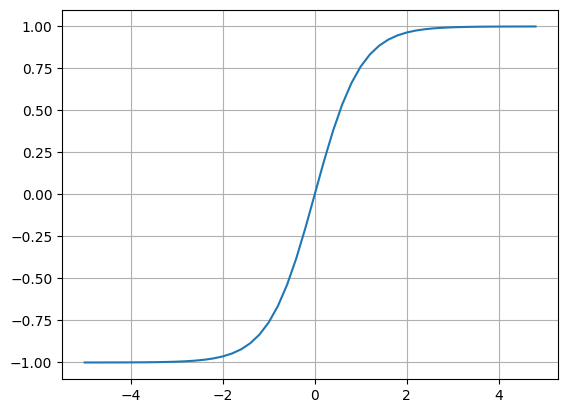

In [5]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

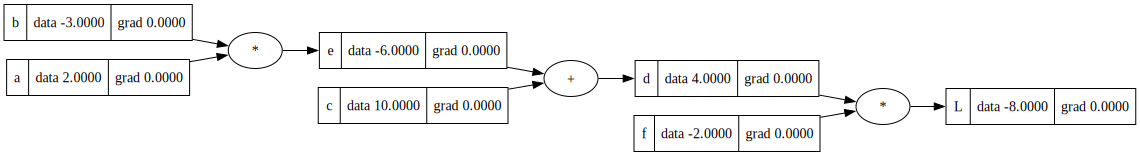

In [6]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(L)
for node in reversed(topo):
  node._backward()


draw_dot(L)

In [7]:
class Neuron:
    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

class MLP:
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x = [2.0, 3.0, -1.0]
n = MLP(3,[4, 16, 16 , 4 , 1])  # Changed final output to 1 neuron so draw_dot works
output = n(x)
print(f"Output: {output}")
# draw_dot(output)


Output: Value(data = -0.6464134589801452, grad=0)


In [8]:
xs = [
    [2.0, 3.0 , -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0 , -1.0 , -1.0 , 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data = -0.6464134589801452, grad=0),
 Value(data = -0.8517741286348779, grad=0),
 Value(data = -0.2984881599148246, grad=0),
 Value(data = -0.8998692826997673, grad=0)]

In [9]:
# loss is a SINGLE number used to define performance of model
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data = 6.834270339978733, grad=0)

In [10]:
loss.backward()

In [11]:
n.layers[0].neurons[0].w[0].grad

0.15654098841134048

In [12]:
# ZERO OUT GRADIENTS
for p in n.parameters():
    p.grad = 0

# Forward pass
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

# Backward pass
loss.backward()

# Update parameters
for p in n.parameters():
    p.data += -0.01 * p.grad

# NEW forward pass
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

# CALL BACKWARD AGAIN to populate gradients
loss.backward()

# NOW draw_dot will show gradients
# draw_dot(loss)

In [27]:
# Simple training loop: zero grads, forward, backward, update
for epoch in range(50):
    # zero gradients
    for p in n.parameters():
        p.grad = 0

    # forward
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

    # backward
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.1 * p.grad

    if epoch % 5 == 0:
        print(f"epoch {epoch}: loss={loss.data}")

# final forward to inspect
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
print('final loss:', loss.data)
# draw the computation graph (requires graphviz installed)
# loss.backward()
# draw_dot(loss)
ypred, ys

epoch 0: loss=0.0005250402255529505
epoch 5: loss=0.0005206448043334768
epoch 10: loss=0.0005163222889338664
epoch 15: loss=0.0005120708787808751
epoch 20: loss=0.0005078888321578339
epoch 25: loss=0.0005037744638176383
epoch 30: loss=0.0004997261427109157
epoch 35: loss=0.0004957422898231101
epoch 40: loss=0.0004918213761143993
epoch 45: loss=0.00048796192055677466
final loss: 0.00048416248826295297


([Value(data = 0.989206525885649, grad=0),
  Value(data = -0.995932385589939, grad=0),
  Value(data = -0.9845108782580451, grad=0),
  Value(data = 0.9894546206573803, grad=0)],
 [1.0, -1.0, -1.0, 1.0])

([Value(data = 0.9586704893272575, grad=0),
  Value(data = -0.9861561836537235, grad=0),
  Value(data = -0.9333280097579806, grad=0),
  Value(data = 0.9616872369863071, grad=0)],
 [1.0, -1.0, -1.0, 1.0])